In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error,r2_score
import warnings 
warnings.filterwarnings('ignore')
import seaborn as sns 

[[   17     6 11230]
 [   18     6  9624]
 [   18     7 13798]
 [   19     7  3215]
 [   20     8 19169]
 [   21     8 14982]
 [   21     9 15419]
 [   40    10 17286]
 [   41    10 14232]
 [   42    10 18092]
 [   42    11 18318]
 [   43    11 16260]
 [   44    11 22247]
 [   44    11 16710]
 [   45    12 28949]
 [   50    14 27309]
 [   54    16 32779]
 [   60    16 29743]
 [   61    16 30341]
 [   67    14 34088]
 [   67    16 32435]
 [   68    17 33909]
 [   76    19 32263]
 [   79    19 42067]
 [   83    22 42295]]


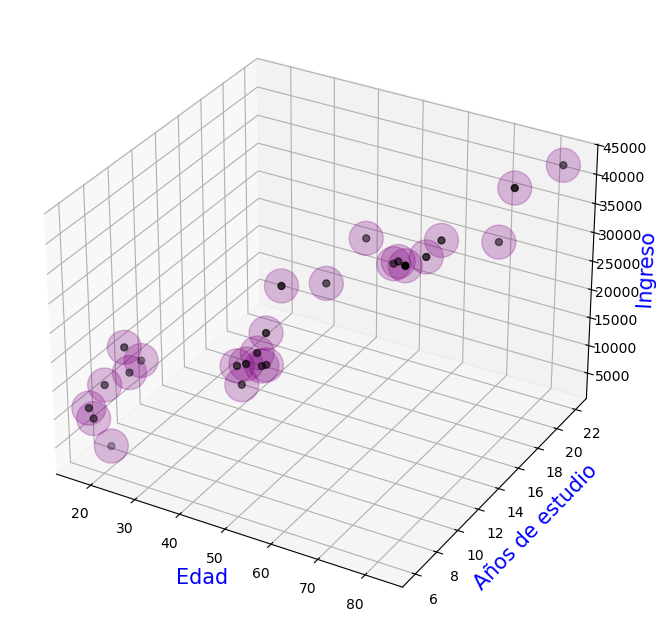

In [2]:
edad=np.array([17,18,18,19,20,
            21,21,40,41,42,
               42,43,44,44,45,
              50,54,60,61,67,
              67,68,76,79,83])
estudio=np.array([6,6,7,7,8,
                  8,9,10,10,10,
                  11,11,11,11,12,
                  14,16,16,16,14,
                  16,17,19,19,22])
ingreso=np.array([11230,9624,13798,3215,19169,
                  14982,15419,17286,14232,18092,
                  18318,16260,22247,16710,28949,
                  27309,32779,29743,30341,34088,
                  32435,33909,32263,42067,42295])

datos=np.stack((edad,estudio,ingreso),axis=1)
print(datos)
fig =plt.figure(figsize=(8,8))
ax=fig.add_subplot(1,1,1,projection="3d")
ax.scatter(datos.T[0],datos.T[1],datos.T[2],marker="o",c="purple",s=600,alpha=0.25)
ax.scatter(datos.T[0],datos.T[1],datos.T[2],marker=".",c="black",s=100)
ax.set_xlabel("Edad",fontsize=15,color="blue")
ax.set_ylabel("Años de estudio",fontsize=15,color="blue")
ax.set_zlabel("Ingreso ",fontsize=15,color="blue")
plt.show()      


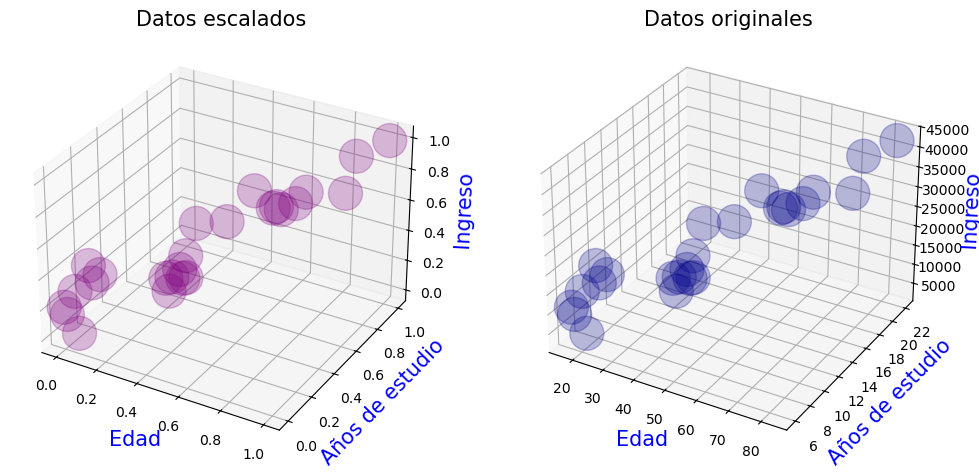

In [6]:
escalador=preprocessing.MinMaxScaler()
escalados=escalador.fit_transform(datos)

#Escalados
fig =plt.figure(figsize=(12,12))
ax=fig.add_subplot(1,2,1,projection="3d")
ax.scatter(escalados.T[0],escalados.T[1],escalados.T[2],marker="o",c="purple",s=600,alpha=0.25)
ax.set_title("Datos escalados",fontsize=15)
ax.set_xlabel("Edad",fontsize=15,color="blue")
ax.set_ylabel("Años de estudio",fontsize=15,color="blue")
ax.set_zlabel("Ingreso ",fontsize=15,color="blue")
ax=fig.add_subplot(1,2,2,projection="3d")
ax.scatter(datos.T[0],datos.T[1],datos.T[2],marker="o",c="darkblue",s=600,alpha=0.25)
ax.set_title("Datos originales",fontsize=15)
ax.set_xlabel("Edad",fontsize=15,color="blue")
ax.set_ylabel("Años de estudio",fontsize=15,color="blue")
ax.set_zlabel("Ingreso ",fontsize=15,color="blue")

plt.show()   
originales=escalados

   


### Agregar datos faltantes

In [5]:
faltantes = escalados.copy()
faltantes[[2,7,12,17,22],2] = np.nan
faltantes

array([[0.        , 0.        , 0.20509212],
       [0.01515152, 0.        , 0.16399693],
       [0.01515152, 0.0625    ,        nan],
       [0.03030303, 0.0625    , 0.        ],
       [0.04545455, 0.125     , 0.40823951],
       [0.06060606, 0.125     , 0.30110031],
       [0.06060606, 0.1875    , 0.3122825 ],
       [0.34848485, 0.25      ,        nan],
       [0.36363636, 0.25      , 0.2819089 ],
       [0.37878788, 0.25      , 0.38068066],
       [0.37878788, 0.3125    , 0.38646366],
       [0.39393939, 0.3125    , 0.33380246],
       [0.40909091, 0.3125    ,        nan],
       [0.40909091, 0.3125    , 0.3453173 ],
       [0.42424242, 0.375     , 0.65849539],
       [0.5       , 0.5       , 0.61653019],
       [0.56060606, 0.625     , 0.75649949],
       [0.65151515, 0.625     ,        nan],
       [0.66666667, 0.625     , 0.69411464],
       [0.75757576, 0.5       , 0.78999488],
       [0.75757576, 0.625     , 0.74769703],
       [0.77272727, 0.6875    , 0.78541453],
       [0.

### Hacer la estimación para cambiar los datos faltantes

In [7]:
imputar = KNNImputer(n_neighbors = 5, weights = "uniform")
imputir_uniforme = imputar.fit_transform(faltantes)

imputar = KNNImputer(n_neighbors = 5, weights = "distance")
imputir_distancia = imputar.fit_transform(faltantes)

np.stack((imputir_uniforme, imputir_distancia), axis = 1)

array([[[0.        , 0.        , 0.20509212],
        [0.        , 0.        , 0.20509212]],

       [[0.01515152, 0.        , 0.16399693],
        [0.01515152, 0.        , 0.16399693]],

       [[0.01515152, 0.0625    , 0.21568577],
        [0.01515152, 0.0625    , 0.12480668]],

       [[0.03030303, 0.0625    , 0.        ],
        [0.03030303, 0.0625    , 0.        ]],

       [[0.04545455, 0.125     , 0.40823951],
        [0.04545455, 0.125     , 0.40823951]],

       [[0.06060606, 0.125     , 0.30110031],
        [0.06060606, 0.125     , 0.30110031]],

       [[0.06060606, 0.1875    , 0.3122825 ],
        [0.06060606, 0.1875    , 0.3122825 ]],

       [[0.34848485, 0.25      , 0.3456346 ],
        [0.34848485, 0.25      , 0.32663701]],

       [[0.36363636, 0.25      , 0.2819089 ],
        [0.36363636, 0.25      , 0.2819089 ]],

       [[0.37878788, 0.25      , 0.38068066],
        [0.37878788, 0.25      , 0.38068066]],

       [[0.37878788, 0.3125    , 0.38646366],
        [0.378

### Grafica de valores faltantes/ estimados

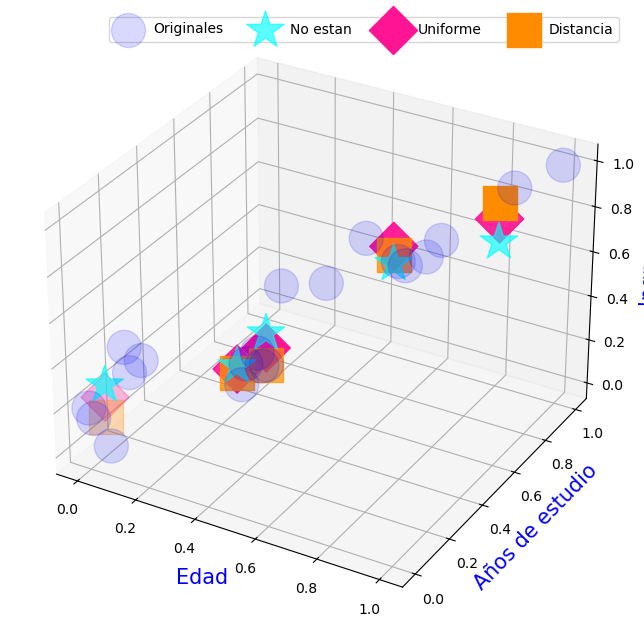

In [11]:
fig = plt.figure(figsize=(8,8))
filtro = ~np.isnan(faltantes.T[2])
ax = fig.add_subplot(1,1,1,projection = "3d")
ax.scatter(escalados.T[0][filtro], escalados.T[1][filtro], escalados.T[2][filtro],
          label="Originales",marker = "o", c="blue", s=600, alpha=0.15)
ax.scatter(escalados.T[0][~filtro], escalados.T[1][~filtro], escalados.T[2][~filtro],
          label="No estan",marker = "*", c="cyan", s=800, alpha=0.65)

ax.scatter(imputir_uniforme.T[0][~filtro], imputir_uniforme.T[1][~filtro], imputir_uniforme.T[2][~filtro],
          label="Uniforme",marker = "D", c="deeppink", s=600)

ax.scatter(imputir_distancia.T[0][~filtro], imputir_distancia.T[1][~filtro], imputir_distancia.T[2][~filtro],
          label="Distancia",marker = "s", c="darkorange", s=600)

ax.set_xlabel("Edad", fontsize=15, color = "blue")
ax.set_ylabel("Años de estudio", fontsize=15, color = "blue")
ax.set_zlabel("Ingreso", fontsize=15, color = "blue")
ax.legend(ncol = 4)
plt.show()